1. Downloading street network...
2. Downloading building footprints...
3. Downloading restaurants...
4. Plotting the map...


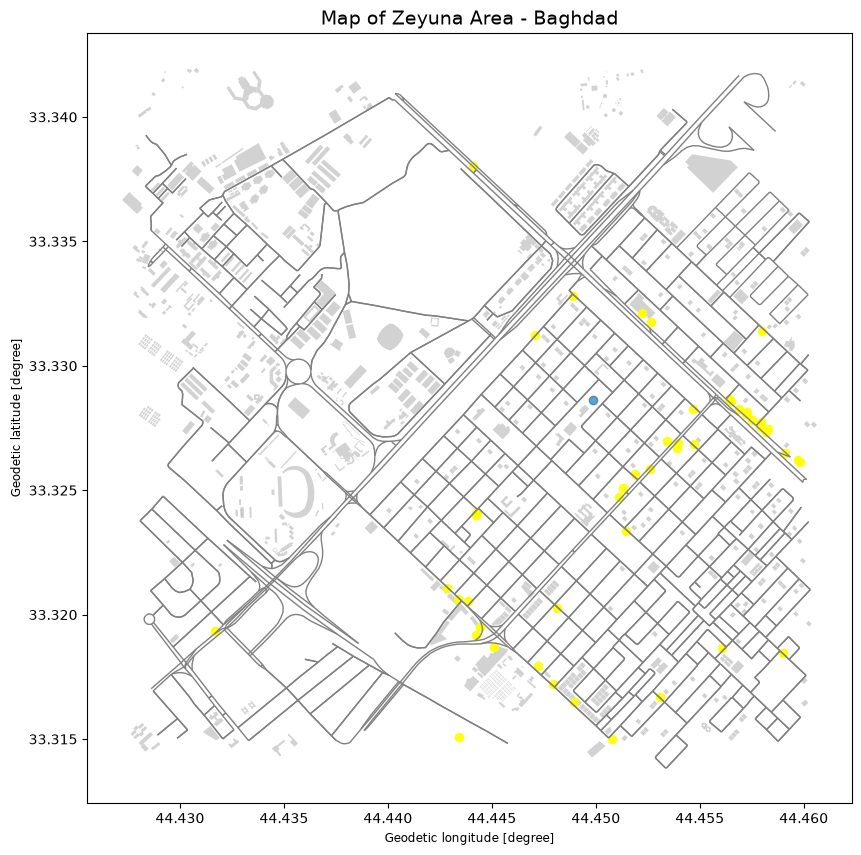

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt

# 1. Define Zeyuna center coordinates (Latitude, Longitude) and search radius (meters)
CENTER_POINT = (33.3283, 44.4442)  # Zeyuna, Baghdad
RADIUS = 1500  # 1.5 km radius

# 2. Download street network around Zeyuna
print("1. Downloading street network...")
graph = ox.graph_from_point(CENTER_POINT, dist=RADIUS, network_type="drive")
nodes, edges = ox.graph_to_gdfs(graph)

# 3. Download building footprints
print("2. Downloading building footprints...")
buildings = ox.features_from_point(CENTER_POINT, tags={"building": True}, dist=RADIUS)

# 4. Download restaurants
print("3. Downloading restaurants...")
restaurants = ox.features_from_point(CENTER_POINT, tags={"amenity": "restaurant"}, dist=RADIUS)

# ----------------------------------------------------
# 5. Plotting the map
print("4. Plotting the map...")
fig, ax = plt.subplots(figsize=(12, 10))

# Plot street network (edges)
edges.plot(ax=ax, linewidth=1, edgecolor="gray")

# Plot buildings
if not buildings.empty:
    buildings.plot(ax=ax, facecolor="silver", alpha=0.7)

# Plot restaurants as yellow points
if not restaurants.empty:
    restaurants.plot(ax=ax, color="yellow", markersize=35, alpha=0.9)

plt.title("Map of Zeyuna Area - Baghdad", fontsize=14)
plt.show()